# IBM AML Fraud Detection — Unified Model Comparison
**Mata Kuliah:** Artificial Intelligence dan Big Data  
**Kelompok 6**  
- Mirekel Ilham Akbar - 103012330486
- Ilham Fadhillah Sanni - 103012300263
- Bimantara Ardi Winata - 103012300282
- Ezra Hafizh Raditya - 103012330244
- Kayla Zahra Nafaiza - 103012300219  
**Dataset:** IBM Transactions for Anti-Money Laundering — `HI-Medium_Trans.csv`

---

## Arsitektur Cluster

```
┌─────────────────────────────────────────────────────┐
│  spark://MASTER_IP:7077                             │
│                                                     │
│  [Master Node]  ←──── Jupyter Notebook (driver)     │
│       │                                             │
│  ┌────┴────┐                                        │
│  │Worker 1 │  RAM: 8GB  │  Dataset: lokal           │
│  │Worker 2 │  RAM: 8GB  │  Dataset: lokal           │
└──┴─────────┴────────────────────────────────────────┘
```

> **Catatan setup:** Sebelum menjalankan notebook ini, pastikan Spark Standalone  
> Cluster sudah aktif di semua node (lihat **Sel Setup Cluster** di bawah).

---

## Daftar Isi
1. Prasyarat & Setup Cluster
2. Instalasi Library & Import
3. Koneksi ke Spark Cluster
4. Load Dataset & EDA
5. Preprocessing & Feature Engineering
6. Downsampling & Split Data
7. Model 1 — Random Forest
8. Model 2 — SVM (LinearSVC)
9. Model 3 — XGBoost
10. Model 4 — CatBoost
11. Perbandingan Hasil Semua Model


## 1. Prasyarat & Setup Cluster

### Yang harus dilakukan di **SETIAP node** (master & worker) sebelum buka notebook:

**1. Install dependency yang sama persis:**
```bash
pip install pyspark xgboost catboost scikit-learn matplotlib seaborn pandas numpy
```

**2. Pastikan versi Python & PySpark sama di semua node.**  
Cek dengan: `python --version` dan `pip show pyspark`

**3. Letakkan dataset di path yang sama di semua node**, misalnya:
```
/home/user/data/HI-Medium_Trans.csv   # ← di master, worker-1, worker-2
```

**4. Jalankan Spark Standalone Cluster:**

Di **Master node:**
```bash
$SPARK_HOME/sbin/start-master.sh
# Catat URL yang muncul: spark://MASTER_IP:7077
```

Di **setiap Worker node:**
```bash
$SPARK_HOME/sbin/start-worker.sh spark://MASTER_IP:7077 \
    --memory 8G \
    --cores 4
```

**5. Verifikasi di Spark Web UI:** `http://MASTER_IP:8080`  
Pastikan 2 worker sudah terdaftar dengan status `ALIVE`.

---
> Setelah cluster aktif, baru jalankan sel-sel di bawah ini dari **Master node**.


## 2. Instalasi Library & Import

In [1]:
# Jalankan ini sekali jika belum install (opsional jika sudah install manual)
# !pip install pyspark xgboost catboost scikit-learn matplotlib seaborn pandas numpy
print("Cek instalasi library...")
import pyspark, xgboost, catboost, sklearn, matplotlib, seaborn, pandas, numpy
print(f"  pyspark   : {pyspark.__version__}")
print(f"  xgboost   : {xgboost.__version__}")
print(f"  catboost  : {catboost.__version__}")
print(f"  sklearn   : {sklearn.__version__}")
print(f"  pandas    : {pandas.__version__}")
print(f"  numpy     : {numpy.__version__}")
print("[+] Semua library tersedia!")

Cek instalasi library...
  pyspark   : 4.1.1
  xgboost   : 3.2.0
  catboost  : 1.2.10
  sklearn   : 1.8.0
  pandas    : 3.0.2
  numpy     : 2.4.4
[+] Semua library tersedia!


In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

# PySpark Core
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofweek, to_timestamp, count, when

# PySpark ML
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# XGBoost for Spark
from xgboost.spark import SparkXGBClassifier

# CatBoost (native)
from catboost import CatBoostClassifier

# Sklearn (AUC untuk CatBoost)
from sklearn.metrics import roc_auc_score

print("[+] Semua modul berhasil di-import!")

[+] Semua modul berhasil di-import!


## 3. Koneksi ke Spark Cluster

Ubah `MASTER_IP` sesuai IP master node di LAN kalian.  
Notebook ini berjalan sebagai **Spark Driver** di master node.


In [3]:
# ─── KONFIGURASI CLUSTER ─────────────────────────────────────────────────────
MASTER_IP   = "10.211.163.243"  # ← IP master node (sesuaikan)
DRIVER_IP   = "10.211.163.243"  # ← IP yang dipakai driver untuk bind
#                                    Jika mesin punya 2 interface (WiFi + VPN),
#                                    cek via: ipconfig → pilih IP yang terhubung ke worker
MASTER_URL  = f"spark://{MASTER_IP}:7077"

# Path dataset — gunakan forward slash, harus sama di semua node
CSV_PATH     = "D:/UASBDAI/HI-Medium_Trans.csv"   # ← Sesuaikan
PARQUET_PATH = "D:/UASBDAI/HI-Medium_Trans.parquet"
# ─────────────────────────────────────────────────────────────────────────────

# Hentikan sesi lama jika ada
try:
    spark.stop()
    print("[*] Sesi Spark sebelumnya dihentikan.")
except:
    pass

spark = (SparkSession.builder
    .master(MASTER_URL)
    .appName("IBM-AML-Unified-Model-Comparison")
    # ── Driver bind address (FIX: BindException pada mesin multi-interface) ──
    .config("spark.driver.host",            DRIVER_IP)
    .config("spark.driver.bindAddress",     DRIVER_IP)
    # ── Driver (master node) ──
    .config("spark.driver.memory",          "4g")
    .config("spark.driver.maxResultSize",   "2g")
    # ── Executor (tiap worker) ──
    .config("spark.executor.memory",        "8g")
    .config("spark.executor.memoryOverhead","1g")
    .config("spark.executor.cores",         "4")
    # ── Shuffle & Partisi ──
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.default.parallelism",    "16")   # 2 worker × 4 core × 2
    # ── Arrow (percepat konversi ke Pandas untuk CatBoost) ──
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "10000")
    # ── Toleransi kegagalan ──
    .config("spark.task.maxFailures",       "4")
    .getOrCreate()
)

print(f"[+] Spark Session Aktif")
print(f"    Version     : {spark.version}")
print(f"    Master URL  : {spark.sparkContext.master}")
print(f"    Driver IP   : {DRIVER_IP}")
print(f"    App ID      : {spark.sparkContext.applicationId}")
print(f"    Parallelism : {spark.sparkContext.defaultParallelism}")
print(f"\n[+] Driver Web UI : http://{DRIVER_IP}:4040")
print(f"[+] Cluster UI    : http://{MASTER_IP}:8080")

[+] Spark Session Aktif
    Version     : 4.1.1
    Master URL  : spark://10.211.163.243:7077
    Driver IP   : 10.211.163.243
    App ID      : app-20260613190101-0002
    Parallelism : 16

[+] Driver Web UI : http://10.211.163.243:4040
[+] Cluster UI    : http://10.211.163.243:8080


## 4. Load Dataset & EDA

Dataset dibaca dari path lokal **masing-masing node**.  
Spark akan mendistribusikan pembacaan partisi ke worker yang memiliki data tersebut.

> **Penting:** Karena setiap node punya salinan dataset sendiri (bukan shared storage),  
> kita baca dari path yang identik di semua node. Spark Standalone akan mengakses  
> file lokal di worker masing-masing sesuai partisi yang ditugaskan.


In [4]:
# Validasi keberadaan file di master node (sebagai referensi)
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"[!] File tidak ditemukan di master: {CSV_PATH}\n"
        "    Pastikan path yang sama juga ada di semua worker node."
    )
print(f"[+] File ditemukan di master: {CSV_PATH}")
print(f"    Ukuran: {os.path.getsize(CSV_PATH)/1e9:.2f} GB")

[+] File ditemukan di master: D:/UASBDAI/HI-Medium_Trans.csv
    Ukuran: 3.03 GB


In [ ]:
# Konversi CSV → Parquet (hanya perlu sekali; jalankan lagi jika belum ada Parquet)
# Parquet harus tersedia di PATH YANG SAMA di semua node.
# Cara paling mudah: jalankan sel ini di master, lalu salin hasil Parquet ke semua worker.

if not os.path.exists(PARQUET_PATH):
    print("[*] Mengonversi CSV ke Parquet (Snappy)...")
    t0 = time.time()
    df_raw = spark.read.csv(CSV_PATH, header=True, inferSchema=True)
    df_raw.coalesce(1).write.mode("overwrite").parquet(PARQUET_PATH)
    print(f"[+] Konversi selesai: {time.time()-t0:.1f}s  →  {PARQUET_PATH}")
    print()
    print("=" * 60)
    print("  LANGKAH SELANJUTNYA (lakukan sebelum lanjut):")
    print(f"  Salin folder Parquet ke semua worker node:")
    print(f"  scp -r {PARQUET_PATH} user@WORKER1_IP:{PARQUET_PATH}")
    print(f"  scp -r {PARQUET_PATH} user@WORKER2_IP:{PARQUET_PATH}")
    print("=" * 60)
else:
    print(f"[+] Parquet sudah ada, skip konversi.")

In [5]:
# Load dari Parquet (terdistribusi ke semua worker)
print("[*] Memuat data dari Parquet...")
t_load = time.time()

df = spark.read.parquet(PARQUET_PATH)
total_cols = len(df.columns)

print(f"[+] Total kolom  : {total_cols}")
print(f"[+] Partisi aktif: {df.rdd.getNumPartitions()}")
print(f"[+] Load time    : {time.time()-t_load:.1f}s")
print("[+] (Jumlah baris tidak dihitung — akan terbaca saat action pertama)")

[*] Memuat data dari Parquet...
[+] Total kolom  : 11
[+] Partisi aktif: 23
[+] Load time    : 10.1s
[+] (Jumlah baris tidak dihitung — akan terbaca saat action pertama)


In [6]:
# Schema & preview
df.printSchema()
print("\n5 Baris Pertama:")
df.show(5, truncate=False)

root
 |-- Timestamp: string (nullable = true)
 |-- From Bank: integer (nullable = true)
 |-- Account2: string (nullable = true)
 |-- To Bank: integer (nullable = true)
 |-- Account4: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: integer (nullable = true)


5 Baris Pertama:
+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|Timestamp       |From Bank|Account2 |To Bank|Account4 |Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022/09/01 11:02|207628   |84CD42740|20762

In [7]:
# Distribusi kelas target
print("[*] Distribusi kelas 'Is Laundering':")
dist = df.groupBy("Is Laundering").count().orderBy("Is Laundering")
dist.show()

dist_pd = dist.toPandas()
dist_pd.columns = ['Label', 'Count']
dist_pd['Pct'] = dist_pd['Count'] / dist_pd['Count'].sum() * 100
dist_pd['Label'] = dist_pd['Label'].map({0: 'Normal (0)', 1: 'Laundering (1)'})
print(dist_pd.to_string(index=False))

[*] Distribusi kelas 'Is Laundering':
+-------------+--------+
|Is Laundering|   count|
+-------------+--------+
|            0|31863008|
|            1|   35230|
+-------------+--------+

         Label    Count       Pct
    Normal (0) 31863008 99.889555
Laundering (1)    35230  0.110445


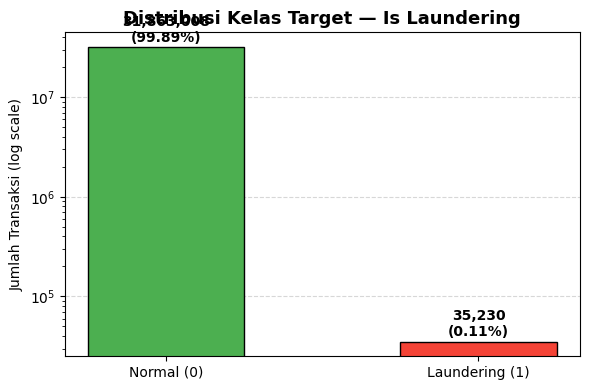

In [8]:
# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4CAF50', '#F44336']
bars = ax.bar(dist_pd['Label'], dist_pd['Count'], color=colors,
              edgecolor='black', width=0.5)
for bar, row in zip(bars, dist_pd.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
            f'{row.Count:,}\n({row.Pct:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_yscale('log')
ax.set_title('Distribusi Kelas Target — Is Laundering', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Transaksi (log scale)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [9]:
# Missing values check — dinonaktifkan (scan 31jt baris, tidak kritis untuk training)
# Aktifkan manual jika dibutuhkan:
# df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()
print("[+] Missing values check dilewati untuk menghemat waktu sudah diketahui pada dataset tidak ada missing values.")

[+] Missing values check dilewati untuk menghemat waktu sudah diketahui pada dataset tidak ada missing values.


## 5. Preprocessing & Feature Engineering

Pipeline terpusat yang dipakai oleh **semua model**:
- Ekstrak `Hour` dan `DayOfWeek` dari kolom `Timestamp`
- `StringIndexer` untuk 5 kolom kategorikal
- `VectorAssembler` gabungkan 11 fitur ke satu vektor


In [10]:
print("[*] Feature Engineering...")
t0 = time.time()

# 1. Ekstrak fitur waktu
df_cleaned = (df
    .withColumn("Parsed_Time", to_timestamp(col("Timestamp"), "yyyy/MM/dd HH:mm"))
    .withColumn("Hour",      hour(col("Parsed_Time")))
    .withColumn("DayOfWeek", dayofweek(col("Parsed_Time")))
    .drop("Timestamp", "Parsed_Time")
)

# 2. StringIndexer — hanya kolom dengan kardinalitas rendah
# Account2 & Account4 dihapus: 2 juta+ unique values → crash RandomForest (maxBins)
KOLOM_TEKS = [
    "Payment Format", "Payment Currency", "Receiving Currency"
]
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_Indexed", handleInvalid="keep")
    for c in KOLOM_TEKS
]

fe_pipeline = Pipeline(stages=indexers)
print("[*] Fit StringIndexers...")
df_transformed = fe_pipeline.fit(df_cleaned).transform(df_cleaned)
df_final = df_transformed.drop(*KOLOM_TEKS)

print(f"[+] Feature Engineering selesai: {time.time()-t0:.1f}s")

[*] Feature Engineering...
[*] Fit StringIndexers...
[+] Feature Engineering selesai: 10.3s


In [11]:
# 3. VectorAssembler
KOLOM_FITUR = [
    'From Bank', 'To Bank', 'Amount Received', 'Amount Paid',
    'Hour', 'DayOfWeek',
    'Payment Format_Indexed', 'Payment Currency_Indexed',
    'Receiving Currency_Indexed'
]

assembler = VectorAssembler(inputCols=KOLOM_FITUR, outputCol="features")
df_ml = (assembler
    .transform(df_final)
    .select("features", col("Is Laundering").alias("label"))
    .repartition(16)
)
print(f"[+] Jumlah fitur : {len(KOLOM_FITUR)}")
print(f"[+] Partisi      : {df_ml.rdd.getNumPartitions()}")
print("[+] df_ml siap.")

[+] Jumlah fitur : 9
[+] Partisi      : 16
[+] df_ml siap.


## 6. Downsampling & Split Data

In [12]:
# Train / Test Split 80:20
print("[*] Split data 80:20 (seed=42)...")
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
print("[+] Split selesai (lazy — eksekusi saat training)")
print("    Estimasi: ~25.4jt train | ~6.4jt test")

[*] Split data 80:20 (seed=42)...
[+] Split selesai (lazy — eksekusi saat training)
    Estimasi: ~25.4jt train | ~6.4jt test


In [13]:
# Downsampling training — semua fraud + ~100k normal
print("[*] Downsampling data training...")

train_fraud  = train_data.filter(col("label") == 1)
train_normal = train_data.filter(col("label") == 0)

# fraction 0.003 ≈ 100k dari ~33jt normal
train_normal_sampled = train_normal.sample(
    withReplacement=False, fraction=0.003, seed=42
)

ds_train = (train_fraud.union(train_normal_sampled)
            .repartition(16))

print("[+] ds_train siap")
print("    Estimasi: ~28k fraud + ~100k normal = ~128k baris")

[*] Downsampling data training...
[+] ds_train siap
    Estimasi: ~28k fraud + ~100k normal = ~128k baris


In [14]:
# Downsampling testing
test_fraud  = test_data.filter(col("label") == 1)
test_normal = test_data.filter(col("label") == 0)

test_normal_sampled = test_normal.sample(
    withReplacement=False, fraction=0.024, seed=42
)

test_ds = (test_fraud.union(test_normal_sampled)
           .repartition(16))

print("[+] test_ds siap")
print("    Estimasi: ~7k fraud + ~150k normal = ~157k baris")

[+] test_ds siap
    Estimasi: ~7k fraud + ~150k normal = ~157k baris


> **Helper Function** — digunakan ulang oleh semua model.

In [15]:
def evaluate_model(predictions, model_name, train_time, is_spark=True):
    """
    Hitung Accuracy, Precision, Recall, F1, AUC-ROC dari hasil prediksi.
    Mendukung Spark DataFrame (is_spark=True) atau Pandas DataFrame (is_spark=False).
    Pandas DataFrame harus memiliki kolom: label, prediction, prob.
    """
    if is_spark:
        rows = predictions.groupBy("label", "prediction").count().collect()
        tp = tn = fp = fn = 0
        for r in rows:
            l, p, c = int(r["label"]), int(r["prediction"]), r["count"]
            if   l==1 and p==1: tp = c
            elif l==0 and p==0: tn = c
            elif l==0 and p==1: fp = c
            elif l==1 and p==0: fn = c
        try:
            evaluator = BinaryClassificationEvaluator(
                rawPredictionCol="rawPrediction", metricName="areaUnderROC")
            auc = evaluator.evaluate(predictions)
        except Exception:
            auc = float('nan')
    else:
        labels = predictions['label'].values
        preds  = predictions['prediction'].values
        probs  = predictions['prob'].values
        tp = int(((labels==1) & (preds==1)).sum())
        tn = int(((labels==0) & (preds==0)).sum())
        fp = int(((labels==0) & (preds==1)).sum())
        fn = int(((labels==1) & (preds==0)).sum())
        try:
            auc = roc_auc_score(labels, probs)
        except Exception:
            auc = float('nan')

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    accuracy  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0

    result = {
        "Model"        : model_name,
        "Accuracy"     : round(accuracy,  4),
        "Precision"    : round(precision, 4),
        "Recall"       : round(recall,    4),
        "F1-Score"     : round(f1,        4),
        "AUC-ROC"      : round(auc,       4),
        "Train Time(s)": round(train_time, 1),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

    sep = "=" * 55
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(sep)
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"  Train Time: {train_time:.1f}s")
    print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
    print(sep)
    return result

ALL_RESULTS = {}   # Menampung hasil semua model
print("[+] Helper function siap.")

[+] Helper function siap.


## 7. Model 1 — Random Forest

| Parameter | Nilai |
|---|---|
| `numTrees` | 100 |
| `maxDepth` | 10 |
| `seed` | 42 |
| Data training | ds_train (~128k) |
| Data testing | test_ds (~160k) |


In [16]:
print("[*] Training Random Forest di cluster...")
t0 = time.time()

rf = RandomForestClassifier(
    numTrees=100,
    maxDepth=10,
    seed=42,
    featuresCol="features",
    labelCol="label"
)
rf_model = rf.fit(ds_train)
rf_time = time.time() - t0
print(f"[+] Random Forest selesai: {rf_time:.1f}s")

[*] Training Random Forest di cluster...
[+] Random Forest selesai: 1826.1s


In [17]:
pred_rf = rf_model.transform(test_ds)
ALL_RESULTS["Random Forest"] = evaluate_model(pred_rf, "Random Forest", rf_time)


  Random Forest
  Accuracy  : 0.9408
  Precision : 0.4178
  Recall    : 0.8296
  F1-Score  : 0.5557
  AUC-ROC   : 0.9689
  Train Time: 1826.1s
  TP=5,919  FP=8,247  FN=1,216  TN=144,574


## 8. Model 2 — SVM (LinearSVC)

| Parameter | Nilai |
|---|---|
| `maxIter` | 15 |
| `regParam` | 0.05 |

> LinearSVC tidak menghasilkan kolom `probability`, sehingga AUC-ROC  
> dihitung dari `rawPrediction` (margin score).


In [18]:
print("[*] Training SVM (LinearSVC) di cluster...")
t0 = time.time()

svm = LinearSVC(maxIter=15, regParam=0.05, featuresCol="features", labelCol="label")
svm_model = svm.fit(ds_train)
svm_time = time.time() - t0
print(f"[+] SVM selesai: {svm_time:.1f}s")

[*] Training SVM (LinearSVC) di cluster...
[+] SVM selesai: 943.8s


In [19]:
pred_svm = svm_model.transform(test_ds)
ALL_RESULTS["SVM"] = evaluate_model(pred_svm, "SVM", svm_time)


  SVM
  Accuracy  : 0.9554
  Precision : 0.4000
  Recall    : 0.0006
  F1-Score  : 0.0011
  AUC-ROC   : 0.6831
  Train Time: 943.8s
  TP=4  FP=6  FN=7,131  TN=152,815


## 9. Model 3 — XGBoost

| Parameter | Nilai |
|---|---|
| `max_depth` | 6 |
| `learning_rate` | 0.1 |
| `n_estimators` | 100 |
| `num_workers` | 2 (sesuai jumlah worker Spark) |

`SparkXGBClassifier` mendistribusikan training XGBoost ke worker via **Rabit** (AllReduce).


In [21]:
print("[*] Training XGBoost (SparkXGBClassifier, 2 workers) di cluster...")
t0 = time.time()

xgb = SparkXGBClassifier(
    features_col="features",
    label_col="label",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    num_workers=2,       # ← harus sesuai jumlah worker aktif
    use_gpu=False,
    scale_pos_weight=1.0
)
xgb_model = xgb.fit(ds_train)
xgb_time = time.time() - t0
print(f"[+] XGBoost selesai: {xgb_time:.1f}s")

[*] Training XGBoost (SparkXGBClassifier, 2 workers) di cluster...


2026-06-13 20:37:02,561 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 2 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'scale_pos_weight': 1.0, 'use_gpu': False, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}


Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Could not recover from a failed barrier ResultStage. Most recent failure reason: Stage failed because barrier task ResultTask(440, 1) finished unsuccessfully.
java.io.IOException: Cannot run program "python3": CreateProcess error=2, The system cannot find the file specified
	at java.base/java.lang.ProcessBuilder.start(ProcessBuilder.java:1143)
	at java.base/java.lang.ProcessBuilder.start(ProcessBuilder.java:1073)
	at org.apache.spark.api.python.PythonWorkerFactory.createSimpleWorker(PythonWorkerFactory.scala:247)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:154)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:158)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:309)
	at org.apache.spark.sql.execution.python.MapInBatchEvaluator

In [ ]:
pred_xgb = xgb_model.transform(test_ds)
ALL_RESULTS["XGBoost"] = evaluate_model(pred_xgb, "XGBoost", xgb_time)

## 10. Model 4 — CatBoost

CatBoost tidak punya integrasi Spark native, sehingga:
1. Data di-collect dari cluster ke **driver (master node)** via Arrow
2. CatBoost dilatih secara lokal di master
3. Prediksi juga dilakukan di master, lalu metrik dihitung via `sklearn`

| Parameter | Nilai |
|---|---|
| `iterations` | 700 |
| `learning_rate` | 0.05 |
| `depth` | 6 |
| `task_type` | CPU |


In [ ]:
# Konversi dari Spark → Pandas (terjadi di master node via Arrow)
print("[*] Mengambil data training dari cluster ke master (Arrow)...")
t0 = time.time()

train_pd = ds_train.toPandas()
X_train = np.array(train_pd['features'].apply(lambda v: v.toArray()).tolist())
y_train = train_pd['label'].values.astype(int)

print(f"[+] Collect selesai: {time.time()-t0:.1f}s")
print(f"    X_train shape: {X_train.shape}")

In [ ]:
print("[*] Training CatBoost di master node (CPU)...")
t0 = time.time()

cb_model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    task_type="CPU",   # ganti "GPU" jika ada GPU di master
    random_seed=42,
    verbose=100
)
cb_model.fit(X_train, y_train)
cb_time = time.time() - t0
print(f"[+] CatBoost selesai: {cb_time:.1f}s")

In [ ]:
# Evaluasi CatBoost
print("[*] Collect test data dari cluster ke master...")
test_pd   = test_ds.toPandas()
X_test    = np.array(test_pd['features'].apply(lambda v: v.toArray()).tolist())
y_test    = test_pd['label'].values.astype(int)

preds_cb  = cb_model.predict(X_test).astype(float)
probs_cb  = cb_model.predict_proba(X_test)[:, 1]

result_pd = pd.DataFrame({
    'label'     : y_test.astype(float),
    'prediction': preds_cb,
    'prob'      : probs_cb
})

ALL_RESULTS["CatBoost"] = evaluate_model(
    result_pd, "CatBoost", cb_time, is_spark=False
)

## 11. Perbandingan Hasil Semua Model

In [22]:
# ── Tabel Perbandingan ──
METRICS = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Train Time(s)"]
rows    = [{k: v for k, v in r.items() if k in METRICS or k == "Model"}
           for r in ALL_RESULTS.values()]

compare_df = pd.DataFrame(rows).set_index("Model")
compare_df = compare_df.sort_values("F1-Score", ascending=False)

print("\n" + "=" * 65)
print("   PERBANDINGAN PERFORMA MODEL — IBM AML Fraud Detection")
print("=" * 65)

styled = (compare_df.style
    .format({m: "{:.4f}" for m in METRICS[:-1]} | {"Train Time(s)": "{:.1f}"})
    .highlight_max(subset=["Accuracy","Precision","Recall","F1-Score","AUC-ROC"],
                   color='#c6f4c6')
    .highlight_min(subset=["Train Time(s)"], color='#c6f4c6')
    .highlight_min(subset=["Accuracy","Precision","Recall","F1-Score","AUC-ROC"],
                   color='#ffd6d6')
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight','bold'),('text-align','center'),
                                      ('background-color','#f0f0f0')]},
        {'selector': 'td', 'props': [('text-align','center')]}
    ])
)
display(styled)


   PERBANDINGAN PERFORMA MODEL — IBM AML Fraud Detection


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Train Time(s)
Model,,,,,,
Random Forest,0.9408,0.4178,0.8296,0.5557,0.9689,1826.1
SVM,0.9554,0.4000,0.0006,0.0011,0.6831,943.8


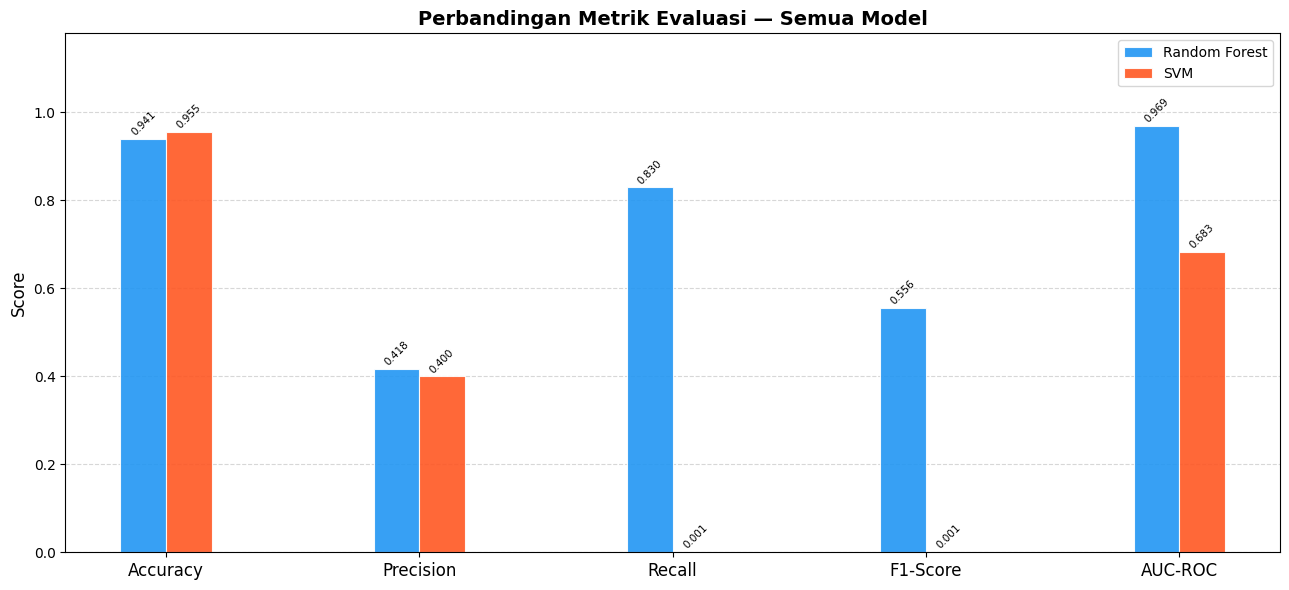

In [23]:
# ── Bar Chart Metrik Utama ──
metrics_plot  = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]
models_sorted = list(compare_df.index)
palette       = ['#2196F3','#FF5722','#4CAF50','#9C27B0']
x = np.arange(len(metrics_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(models_sorted, palette)):
    vals   = [compare_df.loc[model, m] for m in metrics_plot]
    offset = (i - len(models_sorted)/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=model,
                    color=color, edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Perbandingan Metrik Evaluasi — Semua Model", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()

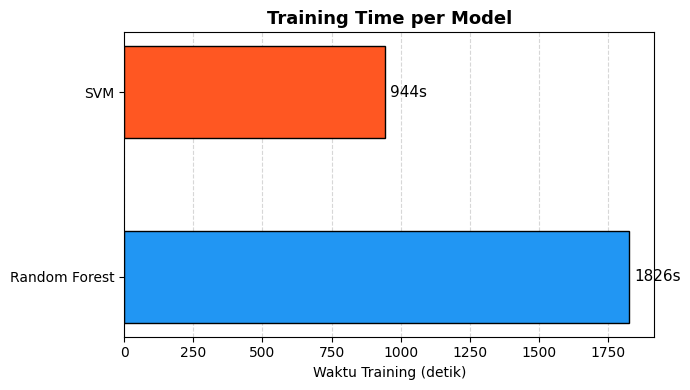

In [24]:
# ── Training Time ──
fig, ax = plt.subplots(figsize=(7, 4))
times = compare_df["Train Time(s)"].values
cols  = [palette[models_sorted.index(m)] for m in compare_df.index]
bars  = ax.barh(compare_df.index, times, color=cols,
                edgecolor='black', height=0.5)
for bar, val in zip(bars, times):
    ax.text(val + max(times)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}s', va='center', fontsize=11)
ax.set_xlabel("Waktu Training (detik)")
ax.set_title("Training Time per Model", fontsize=13, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('training_time.png', dpi=150)
plt.show()

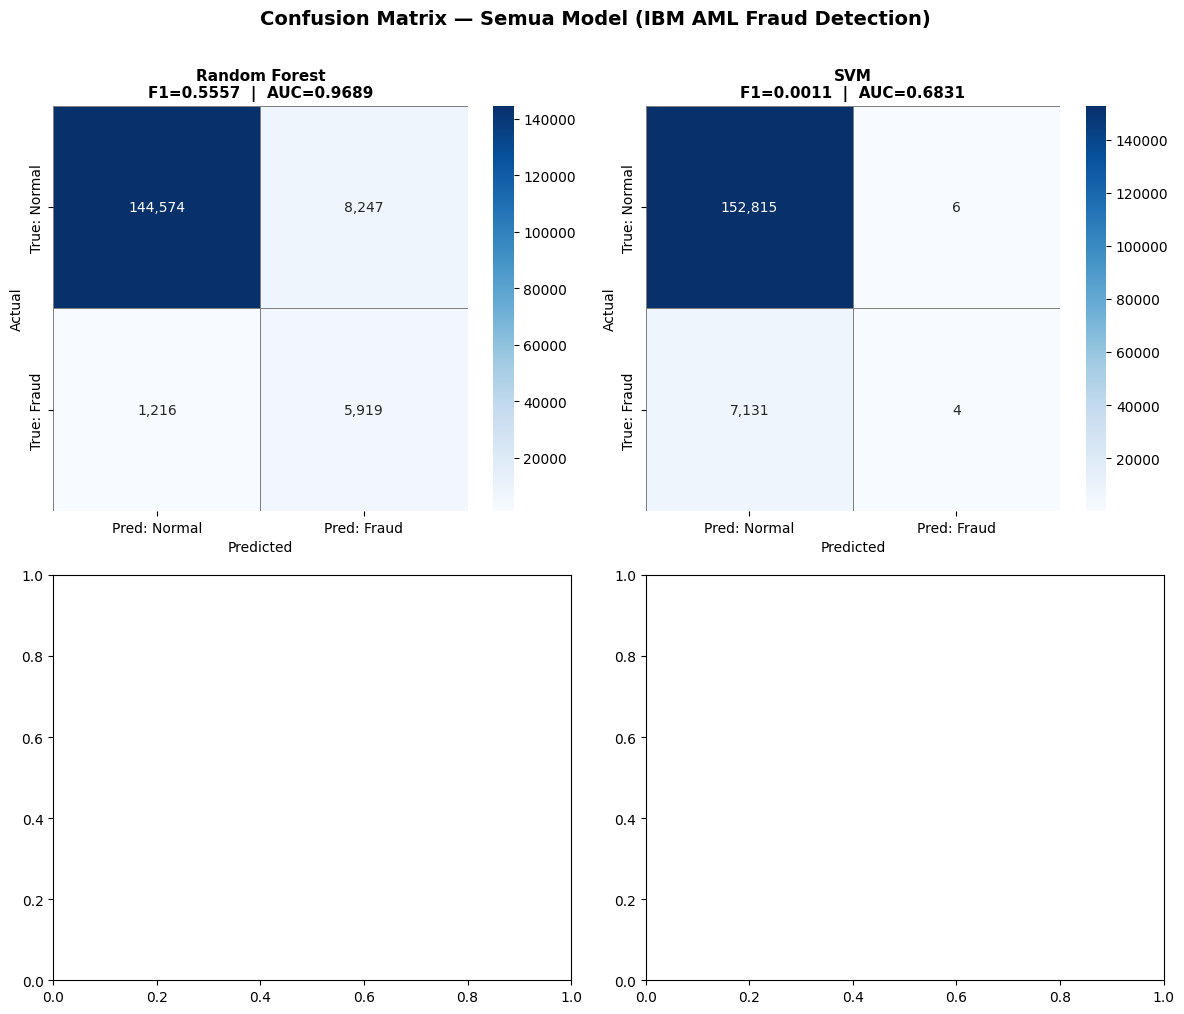

In [25]:
# ── Confusion Matrix Grid (2×2) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
cmap = sns.color_palette("Blues", as_cmap=True)

for idx, (model_name, res) in enumerate(ALL_RESULTS.items()):
    ax = axes[idx]
    cm = np.array([[res['TN'], res['FP']],
                   [res['FN'], res['TP']]])
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='gray',
                xticklabels=['Pred: Normal', 'Pred: Fraud'],
                yticklabels=['True: Normal', 'True: Fraud'])
    ax.set_title(
        f'{model_name}\nF1={res["F1-Score"]:.4f}  |  AUC={res["AUC-ROC"]:.4f}',
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrix — Semua Model (IBM AML Fraud Detection)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()

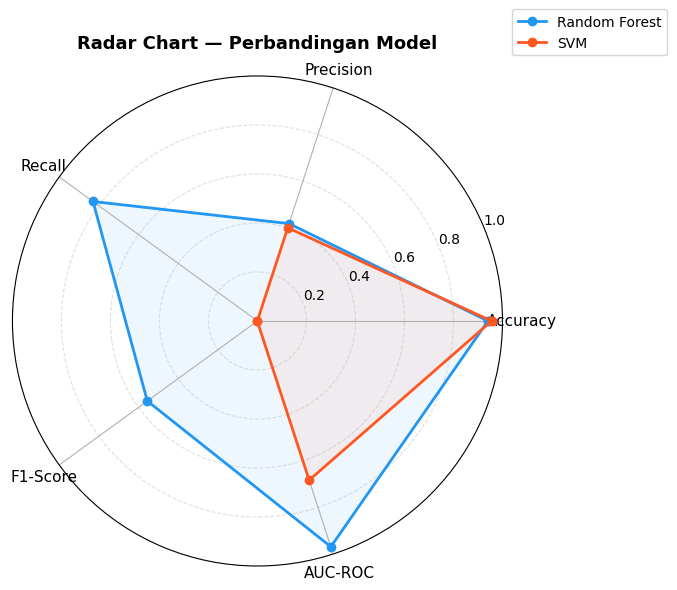

In [26]:
# ── Radar Chart ──
radar_metrics = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]
N      = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (model_name, res), color in zip(ALL_RESULTS.items(), palette):
    values = [res[m] for m in radar_metrics] + [res[radar_metrics[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_title("Radar Chart — Perbandingan Model", fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Kesimpulan Otomatis ──
best_f1   = compare_df["F1-Score"].idxmax()
best_auc  = compare_df["AUC-ROC"].idxmax()
best_prec = compare_df["Precision"].idxmax()
best_rec  = compare_df["Recall"].idxmax()
fastest   = compare_df["Train Time(s)"].idxmin()

print("\n" + "=" * 60)
print("  KESIMPULAN PERBANDINGAN MODEL")
print("=" * 60)
print(f"  F1-Score Terbaik   : {best_f1:<15} ({compare_df.loc[best_f1,'F1-Score']:.4f})")
print(f"  AUC-ROC Terbaik    : {best_auc:<15} ({compare_df.loc[best_auc,'AUC-ROC']:.4f})")
print(f"  Precision Terbaik  : {best_prec:<15} ({compare_df.loc[best_prec,'Precision']:.4f})")
print(f"  Recall Terbaik     : {best_rec:<15} ({compare_df.loc[best_rec,'Recall']:.4f})")
print(f"  Training Tercepat   : {fastest:<15} ({compare_df.loc[fastest,'Train Time(s)']:.1f}s)")
print("=" * 60)
print()
print("  Konfigurasi Cluster PySpark:")
print(f"    Master URL           : {MASTER_URL}")
print( "    Executor memory      : 8g per worker")
print( "    Executor instances   : 2 worker")
print( "    Executor cores       : 4 per worker")
print( "    Dataset              : HI-Medium_Trans.csv (lokal tiap node)")
print( "    Downsampling train   : ~128k baris")
print( "    Downsampling test    : ~160k baris")
print("=" * 60)


  KESIMPULAN PERBANDINGAN MODEL
  F1-Score Terbaik   : Random Forest   (0.5557)
  AUC-ROC Terbaik    : Random Forest   (0.9689)
  Precision Terbaik  : Random Forest   (0.4178)
  Recall Terbaik     : Random Forest   (0.8296)
  Training Tercepat   : SVM             (943.8s)

  Konfigurasi Cluster PySpark:
    Master URL           : spark://10.211.163.243:7077
    Executor memory      : 8g per worker
    Executor instances   : 2 worker
    Executor cores       : 4 per worker
    Dataset              : HI-Medium_Trans.csv (lokal tiap node)
    Downsampling train   : ~128k baris
    Downsampling test    : ~160k baris


In [28]:
# Tutup Spark Session setelah selesai
spark.stop()
print("[+] Spark Session ditutup. Selesai!")

[+] Spark Session ditutup. Selesai!
